In [1]:
from dataset import provider

train_rle_path = '/scratch1/feid/siim-png-images/train-rle.csv'
data_folder = "/scratch1/feid/siim-png-images/input/train_png"

dataloader = provider(
    fold=0,
    total_folds=5,
    data_folder=data_folder,
    df_path=train_rle_path,
    phase="train",
    size=320,
    mean = (0.485, 0.456, 0.406),
    std = (0.229, 0.224, 0.225),
    batch_size=16,
    num_workers=4,
)

/home/feid/repos/CT-Lung-Segmentation-master/dataset.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_mask['has_mask'] = 1
/home/feid/repos/CT-Lung-Segmentation-master/dataset.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_without_mask['has_mask'] = 0


In [2]:
batch = next(iter(dataloader)) # get a batch from the dataloader
images, masks = batch

torch.Size([3, 320, 320])
torch.Size([1, 320, 320])


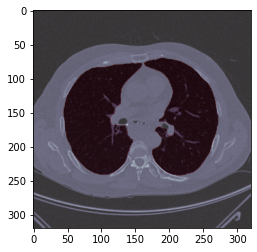

In [5]:
from matplotlib import pyplot as plt
import random
import numpy as np
# plot some random images in the `batch`
idx = random.choice(range(16))
print(images[idx].shape)
print(masks[idx].shape)
plt.imshow(images[idx][0], cmap='bone')
plt.imshow(masks[idx][0], alpha=0.2, cmap='Reds')
plt.show()
if len(np.unique(masks[idx][0])) == 1: # only zeros
    print('Chosen image has no ground truth mask, rerun the cell')

In [8]:
import segmentation_models_pytorch as smp
import torch

model = smp.Unet("resnet34", encoder_weights="imagenet", activation=None)

size = 512
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
num_workers = 8
batch_size = 16
best_threshold = 0.5
min_size = 3500
device = torch.device("cuda:0")
model.eval()
state = torch.load('./save/model.pth', map_location=lambda storage, loc: storage)
model.load_state_dict(state["state_dict"])

<All keys matched successfully>

(320, 320, 3)
(320, 320)


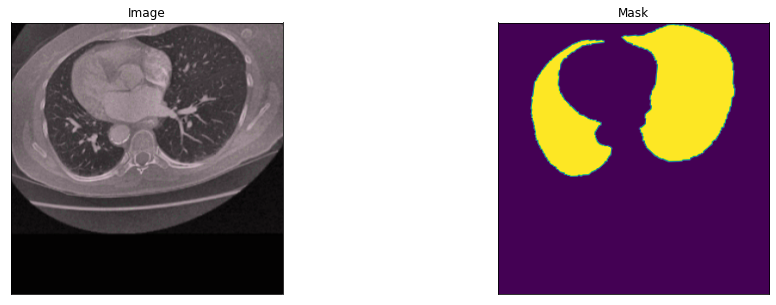

(320, 320, 3)
(320, 320)


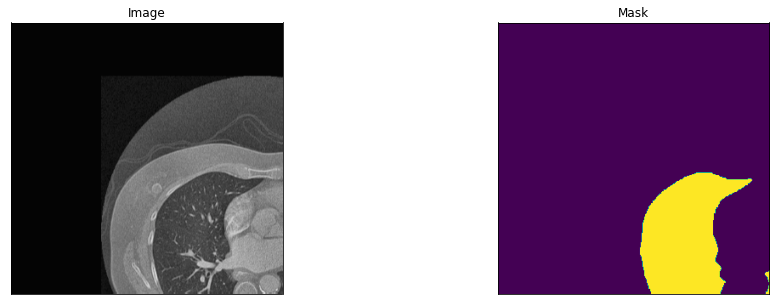

(320, 320, 3)
(320, 320)


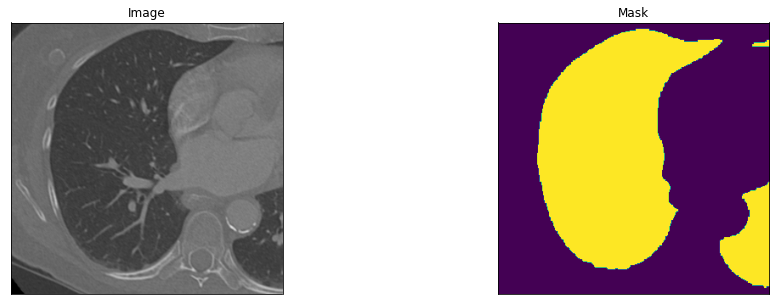

In [3]:
'''Author: Fei Ding
'''
import os
import argparse
from tqdm import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import segmentation_models_pytorch as smp

from utils.dataset import SegCTDataset
from utils.dataset import get_training_trasnforms, get_valid_transforms, get_training_augmentation



# helper function for data visualization
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()

#### Visualize resulted augmented images and masks

augmented_dataset = SegCTDataset(
    txt='../datasets/train.txt', 
    augmentation=get_training_augmentation(), 
)  

#augmented_dataset = SegCTDataset(
#    x_train_dir, 
#    y_train_dir, 
#    augmentation=get_training_augmentation(), 
#    classes=['car'],
#)

# same image with different random transforms
for i in range(3):
    image, mask = augmented_dataset[1]
    print(image.shape)
    print(mask.shape)
    visualize(image=image, mask=mask)

In [4]:
loss = smp.utils.losses.DiceLoss()
metrics = [
    smp.utils.metrics.IoU(threshold=0.5),
]


ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
ACTIVATION = 'sigmoid' # could be None for logits or 'softmax2d' for multicalss segmentation
DEVICE = 'cuda'

# create segmentation model with pretrained encoder
#model = smp.Unet(
#    encoder_name=ENCODER,        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
#    encoder_weights=ENCODER_WEIGHTS,     # use `imagenet` pre-trained weights for encoder initialization
#    in_channels=3,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    #classes=1,           # model output channels (number of classes in your dataset)
    #activation=ACTIVATION,
#)

model = smp.Unet("resnet34", encoder_weights="imagenet", activation=None)

size = 512
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
num_workers = 8
batch_size = 16
best_threshold = 0.5
min_size = 3500
device = torch.device("cuda:0")
model.eval()
state = torch.load('./save/model.pth', map_location=lambda storage, loc: storage)
model.load_state_dict(state["state_dict"])

<All keys matched successfully>

In [5]:
# load best saved checkpoint
#model = torch.load('./save/model.pth')
#model.eval()

#state = torch.load('./model.pth', map_location=lambda storage, loc: storage)
#model.load_state_dict(state["state_dict"])

# create test dataset
test_dataset = SegCTDataset(
        txt='../datasets/test.txt',  
        augmentation=get_valid_transforms(), 
    )  

test_dataloader = DataLoader(test_dataset)

In [4]:
# evaluate model on test set
test_epoch = smp.utils.train.ValidEpoch(
    model=best_model,
    loss=loss,
    metrics=metrics,
    device=DEVICE,
)

logs = test_epoch.run(test_dataloader)

valid: 100%|██████████| 67/67 [00:01<00:00, 63.89it/s, dice_loss - -0.9387, iou_score - 183.4]


In [6]:
# test dataset without transformations for image visualization
test_dataset_vis = CamVidDataset(
    x_test_dir, y_test_dir, 
    classes=CLASSES,
)

In [ ]:

for i in range(5):
    n = np.random.choice(len(test_dataset))
    
    #image_vis = test_dataset_vis[n][0].astype('uint8')
    #image, gt_mask = test_dataset[n]
    
    image, gt_mask = test_dataset[n]
    
    gt_mask = gt_mask.squeeze()
    
    #x_tensor = torch.from_numpy(image).to(DEVICE).unsqueeze(0)
    x_tensor = image.unsqueeze(0)
    pr_mask = model(x_tensor)
    pr_mask = (pr_mask.detach().squeeze().cpu().numpy().round())
    x_tensor = x_tensor.squeeze()
    #image = x_tensor.cpu().numpy().transpose(1,2,0).astype('uint8')
    image = x_tensor[0]
        
    visualize(
        image=image, 
        ground_truth_mask=gt_mask, 
        predicted_mask=pr_mask
    )

In [25]:
import os
import numpy as np # linear algebra



transform = transforms.Compose([
        RandomRescale(0.8,1.2),
        RandomCrop((224,224)),
        RandomColor(),
        RandomFlip(),
        RandomRotation(),
        ToTensor(),
        Normalize(mean=[0.5, 0.5, 0.5],
                  std=[0.5, 0.5, 0.5])
    ])
test_transform = transforms.Compose([
        Resize((224,224)),
        ToTensor(),
        Normalize(mean=[0.5, 0.5, 0.5],
                  std=[0.5, 0.5, 0.5])
    ])
train_dst = CovidCTDataset(txt='../Segmen/train.txt',
                           transforms=transform)
valid_dst = CovidCTDataset(txt='../Segmen/test.txt',
                           transforms=test_transform)
batch_size = 8
print("Train set {}\nValidation set {}\n".format(len(train_dst),len(valid_dst)))

train_loader = DataLoader(train_dst,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(valid_dst,batch_size=batch_size,shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
model = nn.DataParallel(model).to(device)
print("=> loading checkpoint '{}'".format('best.pth.tar'))
checkpoint = torch.load('best.pth.tar', map_location="cpu")

state_dict = checkpoint['state_dict']
                
msg = model.load_state_dict(state_dict)

Train set 200
Validation set 67

=> loading checkpoint 'best.pth.tar'


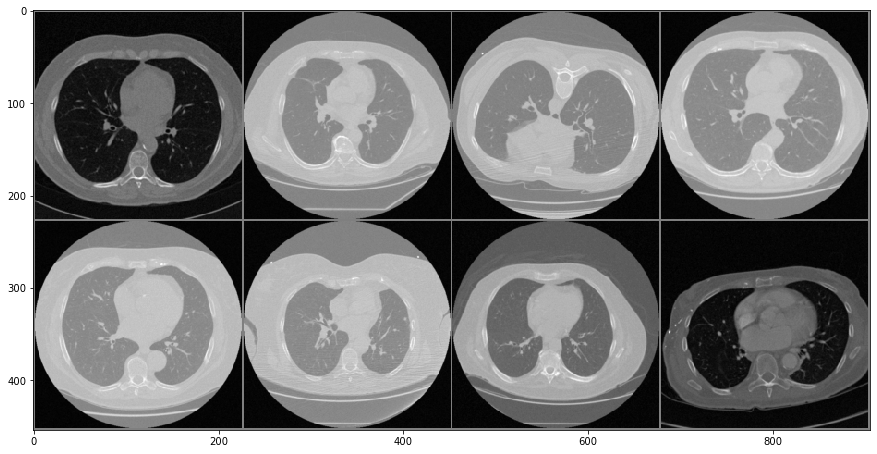

torch.Size([8, 3, 224, 224])
(3, 454, 906)


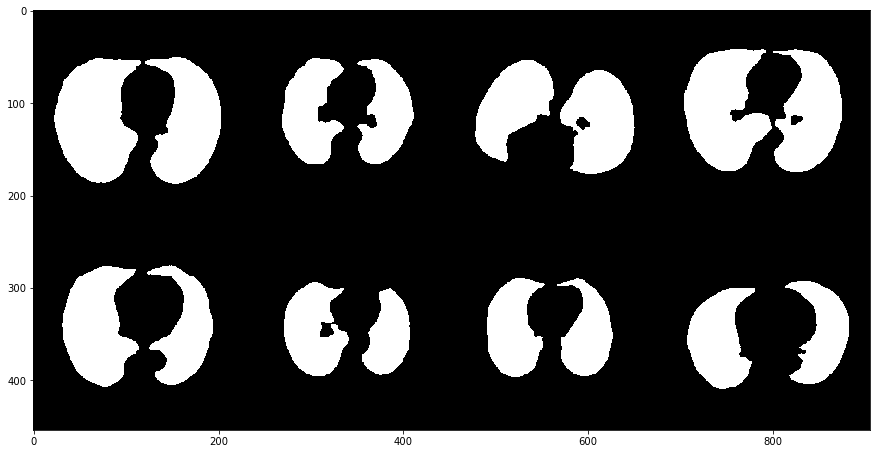

torch.Size([8, 3, 224, 224])
(3, 454, 906)


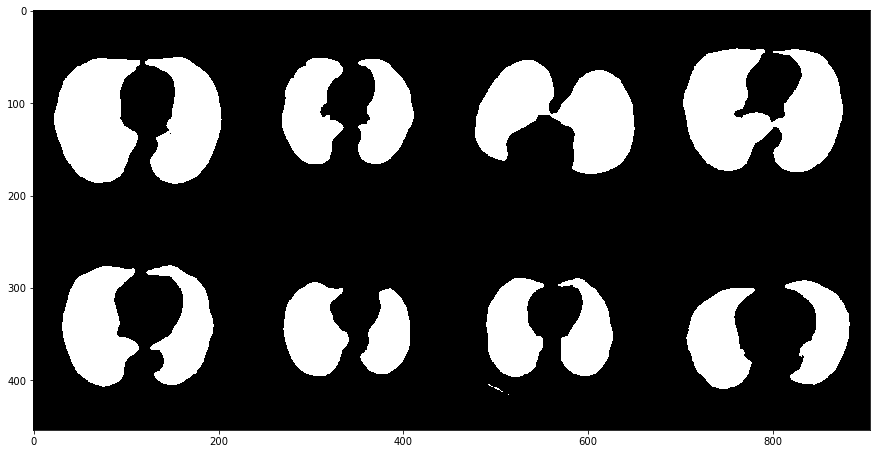

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
%matplotlib inline 
# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(15,15))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

def imshow_pred(img):
    npimg = img.numpy() * 255
    print(npimg.shape)
    plt.figure(figsize=(15,15))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(valid_loader)
batch = dataiter.next()
images, labels = batch['img'], batch['label']
# show images
imshow(torchvision.utils.make_grid(images,nrow=4))
labels_image = torch.cat([labels.unsqueeze(1),labels.unsqueeze(1),labels.unsqueeze(1)],dim=1)
print(labels_image.shape)
imshow_pred(torchvision.utils.make_grid(labels_image,nrow=4))
# print labels
output = model(images.to(device))
_, preds = torch.max(output, 1)
preds = torch.cat([preds.unsqueeze(1),preds.unsqueeze(1),preds.unsqueeze(1)],dim=1)
print(preds.shape)
imshow_pred(torchvision.utils.make_grid(preds.cpu(),nrow=4))